In [4]:

import numpy as np
import tensorflow as tf

# Sentetik veri oluşturma (1000 müşteri)
np.random.seed(42)
X = np.random.rand(1000, 4) # Yaş, Aylık Harcama, Abonelik Süresi, Destek Talebi
# Basit bir mantıkla hedef değişken (y) oluşturalım: 
# Eğer destek talebi ve aylık harcama yüksekse ayrılma (1) ihtimali artsın.
y = (X[:, 1] + X[:, 3] > 1.1).astype(int)

print(f"Feature Matrisi (X) İlk 3 Satır:\n{X[:3]}")
print(f"Hedef Değişken (y) İlk 3 Satır: {y[:3]}")
# Amaç: Veriyi NumPy array formatından TensorFlow'un işleyebileceği Tensör yapısına hazırlamak.

Feature Matrisi (X) İlk 3 Satır:
[[0.37454012 0.95071431 0.73199394 0.59865848]
 [0.15601864 0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985]]
Hedef Değişken (y) İlk 3 Satır: [1 0 1]


In [5]:
from sklearn.model_selection import train_test_split

# Önce %70 Train, %30 Geçici (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Kalan %30'u ikiye bölerek %15 Validation ve %15 Test elde edelim
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Eğitim seti: {X_train.shape}")
print(f"Doğrulama (Val) seti: {X_val.shape}")
print(f"Test seti: {X_test.shape}")
# Amaç: Modelin hiç görmediği verilerle performansını ölçmek (Genelleme yeteneği).

Eğitim seti: (700, 4)
Doğrulama (Val) seti: (150, 4)
Test seti: (150, 4)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    # Giriş katmanı ve 1. Gizli Katman (8 Nöron)
    Dense(units=8, input_shape=(4,)), 
    
    # 2. Gizli Katman (4 Nöron)
    Dense(units=4),
    
    # Çıktı Katmanı (1 Nöron - 0 veya 1 tahmini için)
    Dense(units=1)
])

c:\Users\yaren\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model = Sequential([
    Dense(8, input_shape=(4,), activation='relu'), # Neden ReLU? Gradyan patlamasını önler ve hızlı öğrenir.
    Dense(4, activation='relu'),                   # Negatif değerleri 0 yaparak doğrusal olmayan yapıyı kurar.
    Dense(1, activation='sigmoid')                 # Neden Sigmoid? Çıktıyı 0 ile 1 arasında bir olasılığa sıkıştırır.
])


In [8]:
model.compile(
    optimizer='adam',                # Hata fonksiyonunu minimize eden popüler optimizasyon algoritması.
    loss='binary_crossentropy',      # Sınıflandırma (0-1) problemleri için standart kayıp fonksiyonu.
    metrics=['accuracy']             # Başarıyı 'doğruluk yüzdesi' ile izleyeceğiz.
)
# Not: Eğer bir değer tahmin etseydik (regresyon), loss='mse' (Mean Squared Error) kullanılırdı.

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=50,             # Verinin üzerinden kaç kez geçilecek?
    batch_size=32,         # Her seferinde kaç örnek işlenip ağırlıklar güncellenecek?
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6171 - loss: 0.7058 - val_accuracy: 0.5933 - val_loss: 0.7036
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6171 - loss: 0.6924 - val_accuracy: 0.5933 - val_loss: 0.6925
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6171 - loss: 0.6803 - val_accuracy: 0.5933 - val_loss: 0.6823
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6171 - loss: 0.6694 - val_accuracy: 0.5933 - val_loss: 0.6706
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6171 - loss: 0.6574 - val_accuracy: 0.5933 - val_loss: 0.6606
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6171 - loss: 0.6477 - val_accuracy: 0.5933 - val_loss: 0.6519
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6171 - loss: 0.6382 - val_accuracy: 0.5933 - val_loss: 0.6411
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6171 - loss: 0.6275 - val_accuracy: 0.6000 - val_loss

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Doğruluğu: %{accuracy*100:.2f}")

# Overfitting Yorumu:
# Eğer Eğitim Doğruluğu %95 ama Test Doğruluğu %70 ise model "ezberlemiştir" (Overfitting).
# Bu sentetik veride değerler birbirine yakınsa model sağlıklı öğrenmiştir.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9667 - loss: 0.1468 

Test Doğruluğu: %96.67


In [11]:
# Yeni bir müşteri: Yaş=25, Harcama=0.8, Süre=0.1, Destek Talebi=0.9
yeni_musteri = np.array([[0.25, 0.8, 0.1, 0.9]])
tahmin_olasilik = model.predict(yeni_musteri)
karar = (tahmin_olasilik > 0.5).astype(int)

print(f"Ayrılma Olasılığı: {tahmin_olasilik[0][0]:.4f}")
print(f"Sonuç: {'Churn (Ayrılır)' if karar == 1 else 'Stay (Kalır)'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Ayrılma Olasılığı: 0.9935
Sonuç: Churn (Ayrılır)


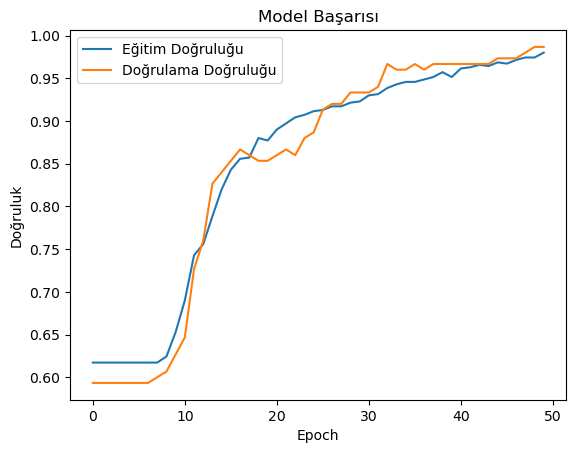

In [12]:
import matplotlib.pyplot as plt

# Eğitim sürecini görselleştirelim
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Model Başarısı')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()